# 13.7 语义分割数据集（Semantic Segmentation Dataset）

## 1. 应用场景（为什么要学）
语义分割用于识别图像中每个像素的语义类别。与目标检测用边界框标注不同，语义分割提供更精细的像素级标注，所以数据集往往较小。

主要应用：
- **自动驾驶**：识别道路、车辆、行人等像素级区域。
- **医疗影像分析**：分割肿瘤、器官等区域。
- **遥感图像分析**：土地覆盖分类。
- **图像编辑**：背景替换、滤镜等。

In [1]:
%matplotlib inline
import os
import torch
import torchvision
from d2l import torch as d2l

## 2. 语义分割与相关任务区别
计算机视觉中还有两个相似任务：**图像分割**（image segmentation）和**实例分割**（instance segmentation）。

- **图像分割**：将图像划分为组成区域，基于像素相关性，无需语义标签，无法保证区域语义。
- **实例分割**：不仅区分语义，还区分不同目标实例（如区分图像中的两只狗）。
- **语义分割**：关注像素级语义类别，不区分实例。

## 3. Pascal VOC2012 数据集介绍
Pascal VOC2012是语义分割领域最重要的数据集之一。包含20个类别，训练集和验证集分别有1464和1449张图像。每张图像都有像素级标注，标注图像与原始图像尺寸相同，不同颜色表示不同类别。

## 4. 数据加载与预处理

### 4.1 下载与读取
首先下载数据集（约2GB），并读取图像和标签。

In [2]:
#@save
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')

voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')

读取所有输入图像和标签到内存中：

In [3]:
#@save
def read_voc_images(voc_dir, is_train=True):
    """读取所有VOC图像并标注"""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt') 
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f: #with语句会自动关闭文件
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

### 4.2 可视化示例
下面我们绘制前5个输入图像及其标签。在标签图像中，不同颜色对应不同的语义类别。

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

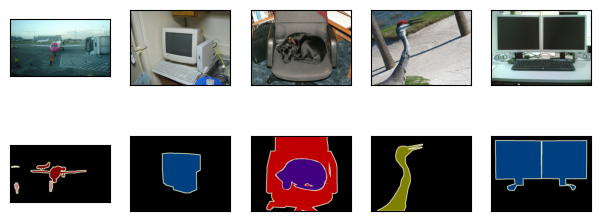

In [4]:
n = 5
imgs = train_features[0:n] + train_labels[0:n] 
imgs = [img.permute(1,2,0) for img in imgs] #torchvision.io.read_image 读出来是（3, H, W），matlab期望是（H, W, 3）。
d2l.show_images(imgs, 2, n) #show_images函数显示图像，参数2表示每行显示2张图像，参数n表示总共显示n张图像

## 5. 类别与颜色映射
Pascal VOC2012包含20个类别加背景。每个类别都有对应的RGB颜色。

In [5]:
#@save
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

#@save
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

### 5.1 颜色到索引的映射
需要将RGB颜色值映射到类别索引，用于训练和评估。

In [6]:
#@save
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射，hashtable大小为256^3"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

### 5.2 示例：查看像素类别
例如，在第一张样本图像中，飞机头部区域的类别索引为1（aeroplane），而背景索引为0。

In [7]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

## 6. 数据预处理
在语义分割中，输入图像和标签在像素上一一对应。为了避免缩放带来的像素不匹配问题，我们使用随机裁剪将图像裁剪为固定尺寸。

In [8]:
#@save
def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

### 6.1 随机裁剪示例
展示对同一图像进行多次随机裁剪的结果。

随机裁剪相当于resize，但是计算更快，而且保持了像素级的对应关系。

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

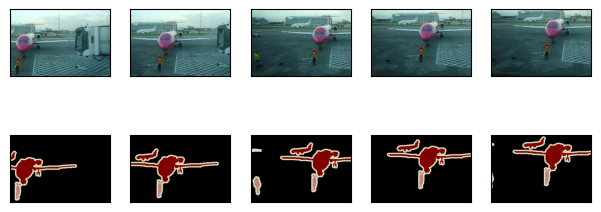

In [9]:
imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
d2l.show_images(imgs[::2] + imgs[1::2], 2, n)

## 7. 自定义数据集类
我们通过继承`Dataset`类创建自定义的语义分割数据集类`VOCSegDataset`，用于加载和预处理VOC数据。

In [10]:
#@save
class VOCSegDataset(torch.utils.data.Dataset):
    """一个用于加载VOC数据集的自定义数据集"""

    def __init__(self, is_train, crop_size, voc_dir):#crop_size是一个元组，表示裁剪后的图像大小；voc_dir是VOC数据集的根目录。
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):#过滤掉那些尺寸小于裁剪尺寸的图像；img.shape[1]是图像的高度，img.shape[2]是图像的宽度,img.shape[0]是图像的通道数。
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

### 7.1 创建数据集实例
指定裁剪尺寸为320×480，创建训练集和测试集。

In [11]:
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

read 1114 examples
read 1078 examples


### 7.2 创建数据加载器
创建训练数据加载器，注意语义分割的标签是三维数组（高度×宽度）。

num_workers参数设置为0，避免Windows系统上的多线程问题。这里折磨了我好久！！！！！！！！！

In [12]:
batch_size = 64
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=0)
for X, Y in train_iter:
    print(X.shape)
    print(Y.shape)
    break

torch.Size([64, 3, 320, 480])
torch.Size([64, 320, 480])


## 8. 整合所有组件
最后，我们定义`load_data_voc`函数来下载并读取Pascal VOC2012语义分割数据集，返回训练集和测试集的数据迭代器。

In [13]:
#@save
def load_data_voc(batch_size, crop_size):
    """加载VOC语义分割数据集"""
    voc_dir = d2l.download_extract('voc2012', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = d2l.get_dataloader_workers()
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

## 9. 小结

* 语义分割是像素级分类任务，用于识别图像中每个像素的语义类别。
* 与目标检测（边界框）不同，语义分割提供更精细的像素级标注。
* Pascal VOC2012是语义分割最重要的数据集之一，包含20个类别。
* 由于输入图像和标签在像素上一一对应，使用随机裁剪而不是缩放来预处理数据。
* 自定义`VOCSegDataset`类可以方便地加载和预处理语义分割数据。